# Notebook 01 — Limpieza de Imágenes de Roscas

**Objetivo**: transformar la imagen raw en una imagen limpia lista para el modelo.

Problemas que resolvemos:
- Artefactos y fragmentos sueltos
- Cabezal del equipo en las esquinas
- Brillos saturados

Dataset: `./images/roscas/Buenas/RB01..RB11` y `./images/roscas/Malas/RM01..RM11`

## 1. Imports y carga de imagen de prueba

Tamano: 2088x1552 px
Valores: min=0, max=255


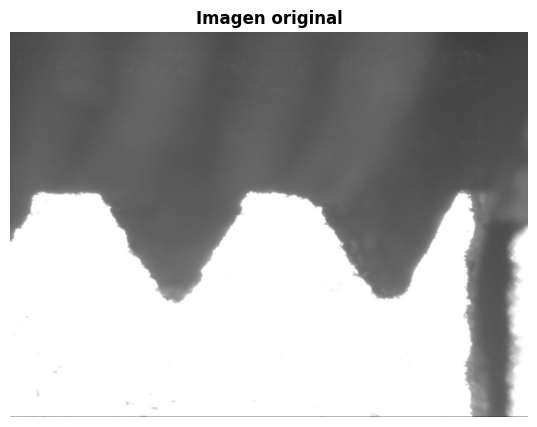

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT = Path('../images/roscas')
ruta = DATA_ROOT / 'Buenas' / 'RB01' / 'Imagen_000501.jpg'
img = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)

print(f'Tamano: {img.shape[1]}x{img.shape[0]} px')
print(f'Valores: min={img.min()}, max={img.max()}')

plt.figure(figsize=(12, 5))
plt.imshow(img, cmap='gray')
plt.title('Imagen original', fontweight='bold')
plt.axis('off')
plt.show()

## 2. Función de limpieza

Pipeline de limpieza:
1. **Neutralizar brillos** saturados (>240) para que no confundan a Otsu
2. **Otsu** — umbralización automática: separa rosca (oscura) de fondo (claro)
3. **Componente mayor** — elimina artefactos pequeños y fragmentos sueltos
4. **Detección de cabezal** — el cabezal es una banda vertical alta en las esquinas, se elimina buscando el último valle en el span de columnas
5. **Segunda limpieza** — componente mayor otra vez para eliminar restos
6. **Recorte vertical** — nos quedamos solo con la franja del borde

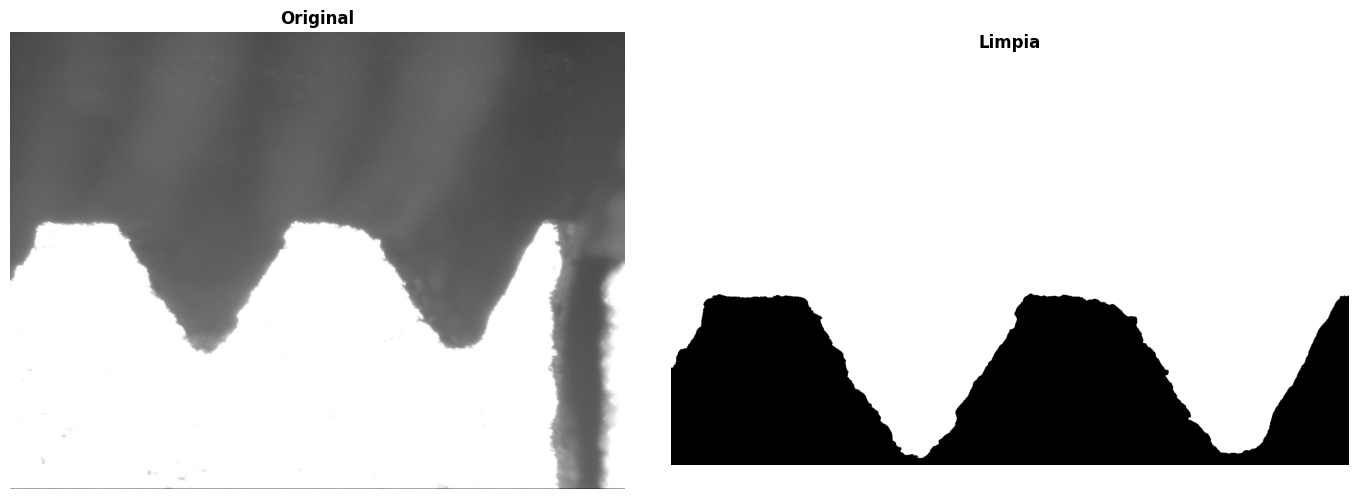

In [2]:
def limpiar_imagen(ruta: str) -> np.ndarray:
    """
    Limpia una imagen de rosca eliminando artefactos, cabezal y ruido.
    Devuelve mascara binaria recortada lista para el modelo.
    """
    img = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    mitad = h // 2

    # 1. Neutralizar brillos saturados
    img[img > 240] = 255

    # 2. Umbralizar con Otsu
    _, binaria = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    binaria = cv2.bitwise_not(binaria)
    rosca_blanca = cv2.bitwise_not(binaria)

    # 3. Componente mayor (elimina artefactos)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(rosca_blanca)
    areas = stats[1:, cv2.CC_STAT_AREA]
    mayor = np.argmax(areas) + 1
    mascara = (labels == mayor).astype(np.uint8) * 255

    # 4. Detectar y eliminar cabezal por span vertical en mitad inferior
    mascara_inferior = mascara[mitad:, :]
    span_columnas = np.zeros(w)
    for col in range(w):
        pixeles = np.where(mascara_inferior[:, col] > 0)[0]
        if len(pixeles) > 0:
            span_columnas[col] = (pixeles[-1] - pixeles[0]) / (h // 2)

    # Ultimo valle de derecha a izquierda = limite del cabezal
    ultimo_valle = w
    for col in range(w - 1, -1, -1):
        if span_columnas[col] < 0.7:
            ultimo_valle = col
            break
    mascara = mascara[:, :ultimo_valle]

    # 5. Componente mayor otra vez para eliminar restos
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mascara)
    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        mayor = np.argmax(areas) + 1
        mascara = (labels == mayor).astype(np.uint8) * 255

    # 6. Recorte vertical
    filas = np.where(mascara.any(axis=1))[0]
    if len(filas) == 0:
        return mascara
    fila_top = filas[0]
    fila_bot = filas[-1]
    margen = 20
    return mascara[max(0, fila_top - margen):min(h, fila_bot + margen), :]


# Probar con la imagen de prueba
resultado = limpiar_imagen(str(ruta))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')
axes[1].imshow(resultado, cmap='gray')
axes[1].set_title('Limpia', fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 3. Validar con todas las imágenes de RB01 (buenas)

Total imagenes RB01: 12


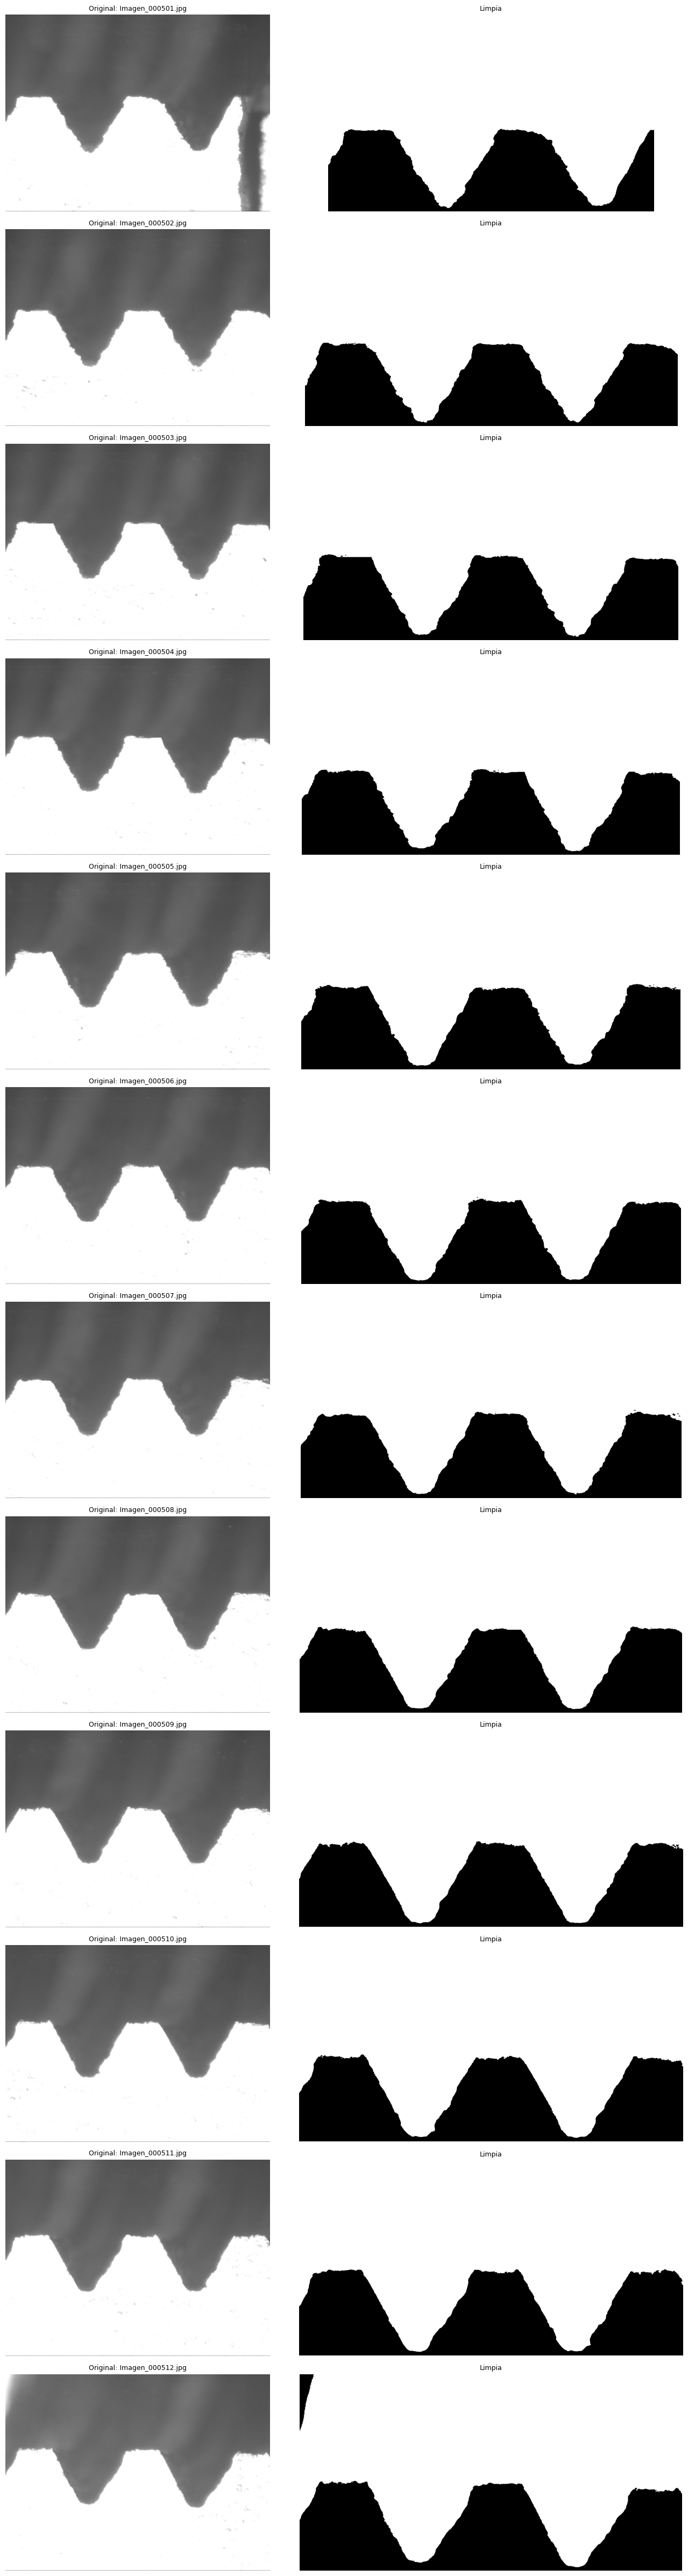

In [3]:
carpeta_rb01 = DATA_ROOT / 'Buenas' / 'RB01'
imagenes_rb01 = sorted(carpeta_rb01.glob('*.jpg'))

print(f'Total imagenes RB01: {len(imagenes_rb01)}')

fig, axes = plt.subplots(len(imagenes_rb01), 2, figsize=(14, 4 * len(imagenes_rb01)))

for i, ruta in enumerate(imagenes_rb01):
    img_test = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
    resultado = limpiar_imagen(str(ruta))
    axes[i, 0].imshow(img_test, cmap='gray')
    axes[i, 0].set_title(f'Original: {ruta.name}', fontsize=9)
    axes[i, 0].axis('off')
    axes[i, 1].imshow(resultado, cmap='gray')
    axes[i, 1].set_title('Limpia', fontsize=9)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## 4. Validar con todas las imágenes de RM01 (malas)

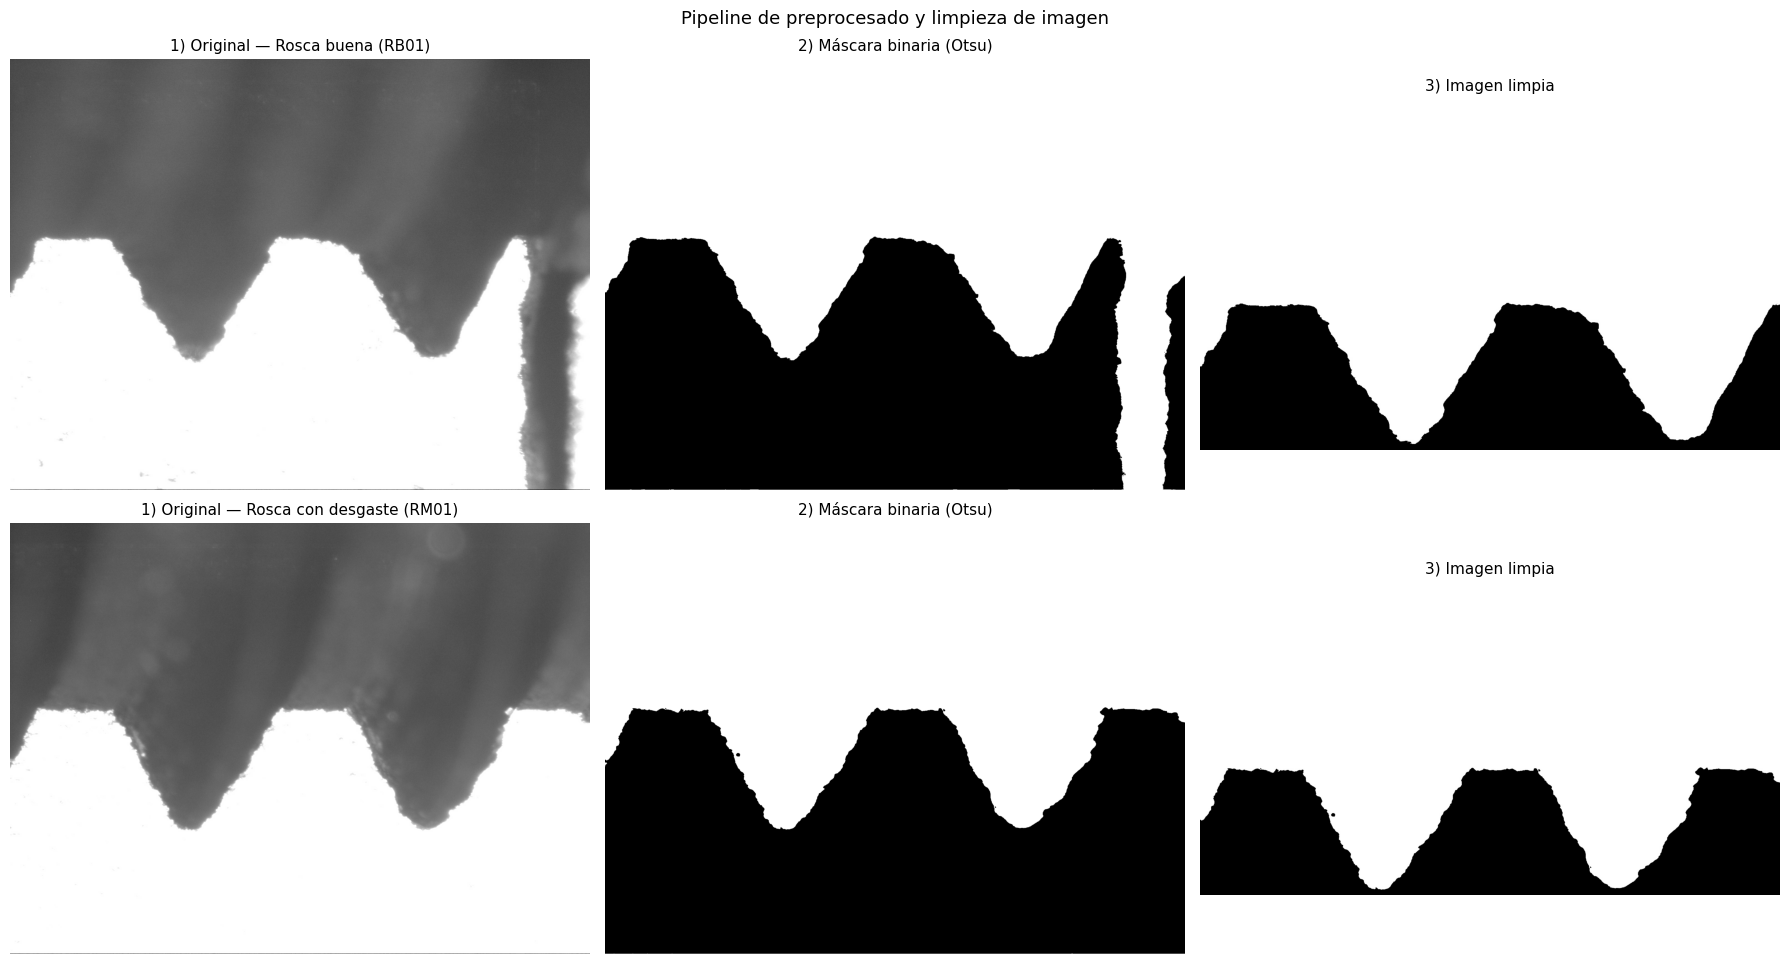

Figura guardada


In [4]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

Path(r"..\figures").mkdir(exist_ok=True)

# Dos imágenes representativas — una buena y una mala
imagenes = [
    {
        "original": Path(
            r"..\images\roscas\Buenas\RB01\Imagen_000501.jpg"
        ),
        "limpia": Path(
            r"..\images\roscas_limpias\Buenas\RB01\Imagen_000501.jpg"
        ),
        "label": "Rosca buena (RB01)",
    },
    {
        "original": Path(
            r"..\images\roscas\Malas\RM01\Imagen_000501.jpg"
        ),
        "limpia": Path(
            r"..\images\roscas_limpias\Malas\RM01\Imagen_000501.jpg"
        ),
        "label": "Rosca con desgaste (RM01)",
    },
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for fila, img_info in enumerate(imagenes):
    original = cv2.imread(str(img_info["original"]), cv2.IMREAD_GRAYSCALE)
    limpia = cv2.imread(str(img_info["limpia"]), cv2.IMREAD_GRAYSCALE)
    _, binaria = cv2.threshold(
        original, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    axes[fila, 0].imshow(original, cmap="gray")
    axes[fila, 0].set_title(f"1) Original — {img_info['label']}", fontsize=11)
    axes[fila, 0].axis("off")

    axes[fila, 1].imshow(binaria, cmap="gray")
    axes[fila, 1].set_title("2) Máscara binaria (Otsu)", fontsize=11)
    axes[fila, 1].axis("off")

    axes[fila, 2].imshow(limpia, cmap="gray")
    axes[fila, 2].set_title("3) Imagen limpia", fontsize=11)
    axes[fila, 2].axis("off")

plt.suptitle("Pipeline de preprocesado y limpieza de imagen", fontsize=13)
plt.tight_layout()
plt.savefig(
    r"..\figures\figura_preprocesado.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
print("Figura guardada")

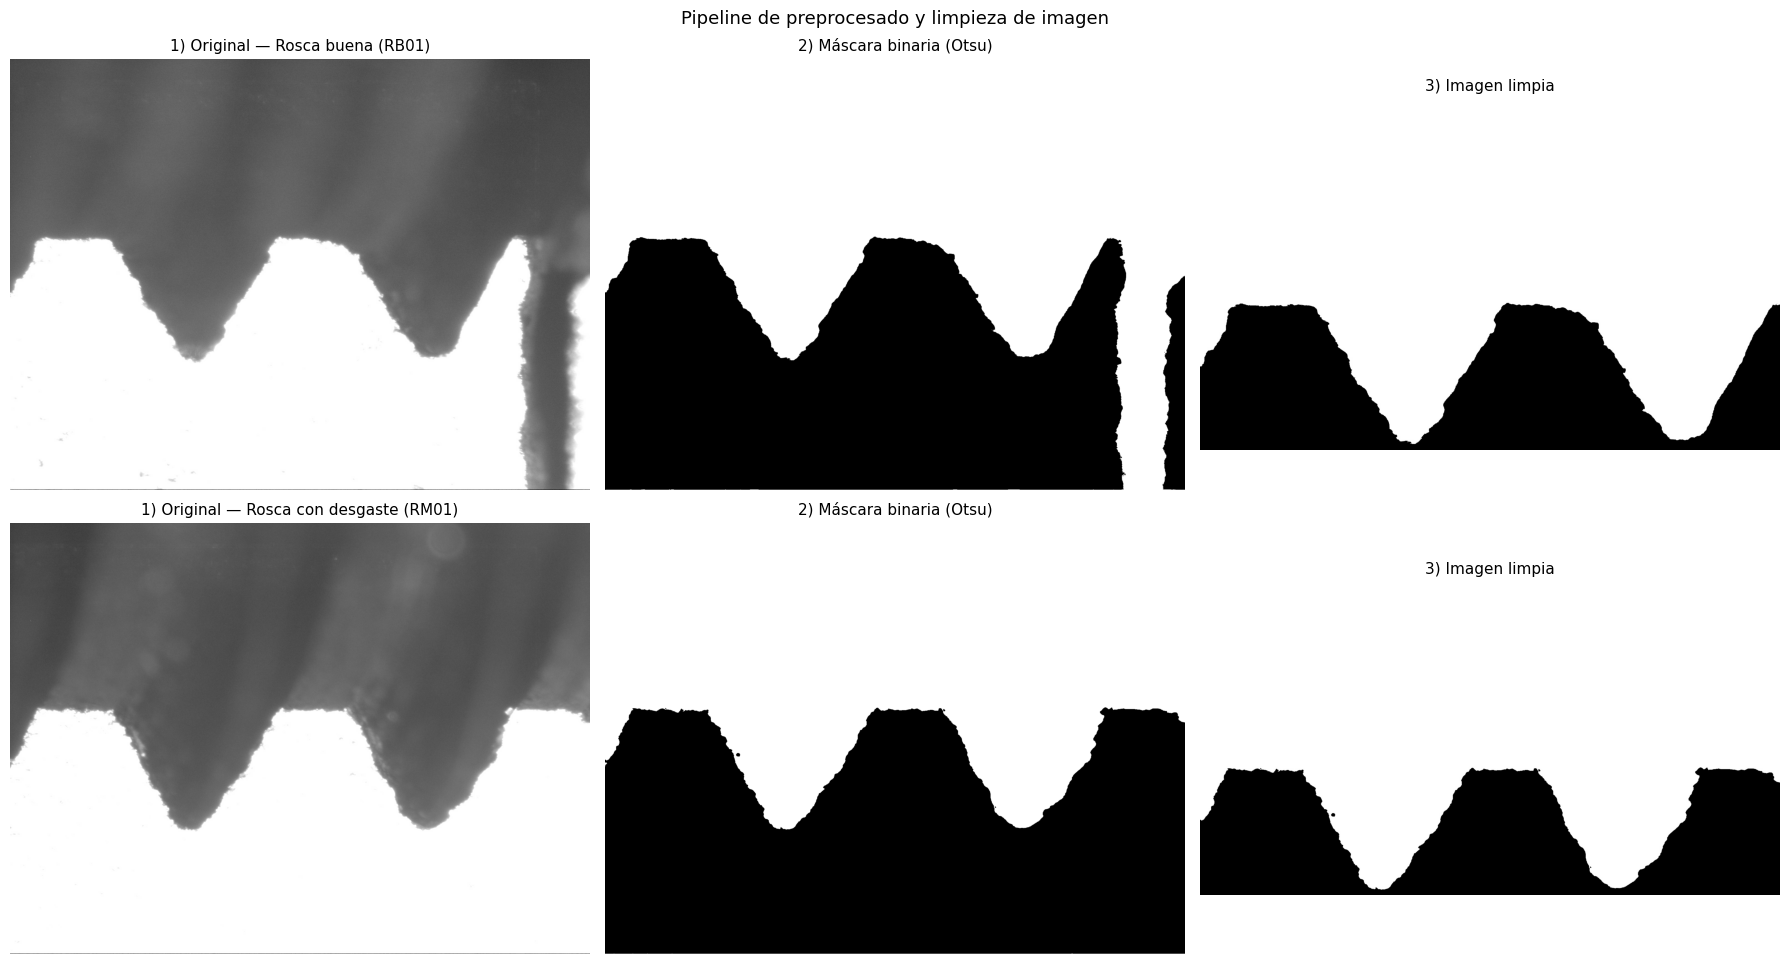

Figura guardada


In [5]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

Path(r"..\figures").mkdir(exist_ok=True)

# Dos imágenes representativas — una buena y una mala
imagenes = [
    {
        "original": Path(
            r"..\images\roscas\Buenas\RB01\Imagen_000501.jpg"
        ),
        "limpia": Path(
            r"..\images\roscas_limpias\Buenas\RB01\Imagen_000501.jpg"
        ),
        "label": "Rosca buena (RB01)",
    },
    {
        "original": Path(
            r"..\images\roscas\Malas\RM01\Imagen_000501.jpg"
        ),
        "limpia": Path(
            r"..\images\roscas_limpias\Malas\RM01\Imagen_000501.jpg"
        ),
        "label": "Rosca con desgaste (RM01)",
    },
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for fila, img_info in enumerate(imagenes):
    original = cv2.imread(str(img_info["original"]), cv2.IMREAD_GRAYSCALE)
    limpia = cv2.imread(str(img_info["limpia"]), cv2.IMREAD_GRAYSCALE)
    _, binaria = cv2.threshold(
        original, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    axes[fila, 0].imshow(original, cmap="gray")
    axes[fila, 0].set_title(f"1) Original — {img_info['label']}", fontsize=11)
    axes[fila, 0].axis("off")

    axes[fila, 1].imshow(binaria, cmap="gray")
    axes[fila, 1].set_title("2) Máscara binaria (Otsu)", fontsize=11)
    axes[fila, 1].axis("off")

    axes[fila, 2].imshow(limpia, cmap="gray")
    axes[fila, 2].set_title("3) Imagen limpia", fontsize=11)
    axes[fila, 2].axis("off")

plt.suptitle("Pipeline de preprocesado y limpieza de imagen", fontsize=13)
plt.tight_layout()
plt.savefig(
    r"..\figures\figura_preprocesado.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
print("Figura guardada")

In [6]:
import pandas as pd

data = {
    "Rosca": ["RB01", "RB02", "RB03", "Total"],
    "Clase": ["Buena", "Buena", "Buena", ""],
    "Imágenes": [11, 11, 11, 33],
    "Anotaciones cresta": [22, 22, 22, 66],
    "Anotaciones paso": [29, 32, 33, 94],
    "Total anotaciones": [51, 54, 55, 160],
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

Rosca Clase  Imágenes  Anotaciones cresta  Anotaciones paso  Total anotaciones
 RB01 Buena        11                  22                29                 51
 RB02 Buena        11                  22                32                 54
 RB03 Buena        11                  22                33                 55
Total              33                  66                94                160


In [7]:
import json
import pandas as pd
from pathlib import Path

ANNOTATIONS_DIR = Path(r"..\annotations")

filas = []
for i in range(1, 12):
    rosca_id = f"RB{i:02d}"
    json_path = ANNOTATIONS_DIR / f"{rosca_id}_coco.json"

    if not json_path.exists():
        continue

    with open(json_path) as f:
        coco = json.load(f)

    n_imgs = len(coco["images"])
    n_cresta = sum(1 for a in coco["annotations"] if a["category_id"] == 0)
    n_paso = sum(1 for a in coco["annotations"] if a["category_id"] == 1)
    n_total = len(coco["annotations"])

    filas.append(
        {
            "Rosca": rosca_id,
            "Clase": "Buena",
            "Imágenes": n_imgs,
            "Anotaciones cresta": n_cresta,
            "Anotaciones paso": n_paso,
            "Total anotaciones": n_total,
        }
    )

df = pd.DataFrame(filas)

# Fila de totales
totales = {
    "Rosca": "Total",
    "Clase": "",
    "Imágenes": df["Imágenes"].sum(),
    "Anotaciones cresta": df["Anotaciones cresta"].sum(),
    "Anotaciones paso": df["Anotaciones paso"].sum(),
    "Total anotaciones": df["Total anotaciones"].sum(),
}
df = pd.concat([df, pd.DataFrame([totales])], ignore_index=True)

print(df.to_string(index=False))

Rosca Clase  Imágenes  Anotaciones cresta  Anotaciones paso  Total anotaciones
 RB01 Buena        12                  24                33                 57
 RB02 Buena        11                  22                33                 55
 RB03 Buena        11                  22                33                 55
 RB04 Buena        12                  24                35                 59
 RB05 Buena        12                  24                36                 60
 RB06 Buena        12                  24                35                 59
 RB07 Buena        12                  24                35                 59
 RB08 Buena        12                  24                35                 59
 RB09 Buena        12                  24                35                 59
 RB10 Buena        12                  22                35                 57
 RB11 Buena        12                  24                35                 59
Total             130                 258           